# Generate Paradata, Microdata in long format.

### Download Data from storage system

Please Note that you need [aws cli](https://docs.aws.amazon.com/cli/latest/userguide/getting-started-install.html#getting-started-install-instructions) installed and set up with credentials to download and uplaod the data. If you do not need the sync from S#, you can simply comment with `#` the next line.


In [1]:
! make sync_data_down

aws s3 sync s3://surveytool/pmpmd/latest/ \
	data/pmpmd
download: s3://surveytool/pmpmd/latest/.DS_Store to data/pmpmd/.DS_Store           
download: s3://surveytool/pmpmd/latest/10_RAW/pmpmd_17census_1_Paradata_All/paradata.tab to data/pmpmd/10_RAW/pmpmd_17census_1_Paradata_All/paradata.tab
download: s3://surveytool/pmpmd/latest/10_RAW/pmpmd_17census_1_Paradata_All/export__info.json to data/pmpmd/10_RAW/pmpmd_17census_1_Paradata_All/export__info.json
download: s3://surveytool/pmpmd/latest/10_RAW/pmpmd_17census_1_Tabular_All/Questionnaire/content/Categories/6cb2e6acd520d68cf26e92dc0132083f.xlsx to data/pmpmd/10_RAW/pmpmd_17census_1_Tabular_All/Questionnaire/content/Categories/6cb2e6acd520d68cf26e92dc0132083f.xlsx
download: s3://surveytool/pmpmd/latest/10_RAW/pmpmd_17census_1_Paradata_All/export__readme.txt to data/pmpmd/10_RAW/pmpmd_17census_1_Paradata_All/export__readme.txt
download: s3://surveytool/pmpmd/latest/10_RAW/pmpmd_17census_1_Paradata_All/paradata.do to data/pmpmd/10_RAW/pmp

In [1]:
from ploomber.spec import DAGSpec
spec = DAGSpec('./pipeline.yaml')
dag = spec.to_dag()
build = dag.build(force=True)

/Users/gabriele/anaconda3/envs/rissk/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/gabriele/anaconda3/envs/rissk/lib/python3.10/site-packages/ploomber/spec/dagspec.py:410: UserWarning: The following placeholders are declared in the environment but unused in the spec: {'QUESTIONAIRE', 'VERSION'}
  warnings.warn(
/Users/gabriele/anaconda3/envs/rissk/lib/python3.10/site-packages/ploomber/dag/dag.py:456: UserWarning: 
=========================== DAG render with warnings ===========================
- NotebookRunner: process_paradata -> MetaProduct({'nb': File('outputs...radata.ipynb'), 'paradata': File('data/pm...data.parquet'), 'paradata_active': File('data/pm...tive.parquet')}) -
- /Users/gabriele/App/rowsquared/rissk/pipelines/feature_engineering/process_paradata.py -
These parameters are not use

100%|██████████| 2/2 [00:00<00:00, 9892.23it/s]
/Users/gabriele/anaconda3/envs/rissk/lib/python3.10/site-packages/ploomber/dag/dag.py:456: UserWarning: 
=========================== DAG render with warnings ===========================
- NotebookRunner: process_paradata -> MetaProduct({'nb': File('outputs...radata.ipynb'), 'paradata': File('data/pm...data.parquet'), 'paradata_active': File('data/pm...tive.parquet')}) -
- /Users/gabriele/App/rowsquared/rissk/pipelines/feature_engineering/process_paradata.py -
These parameters are not used in the task's source code: 'limit_unit'
=============================== Summary (1 task) ===============================
NotebookRunner: process_paradata -> MetaProduct({'nb': File('outputs...radata.ipynb'), 'paradata': File('data/pm...data.parquet'), 'paradata_active': File('data/pm...tive.parquet')})
=========================== DAG render with warnings ===========================

  warnings.warn(str(warnings_))


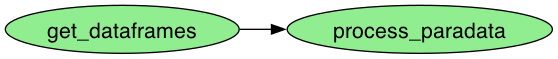

In [20]:

dag.plot()

In [21]:
build

name,Ran?,Elapsed (s),Percentage
get_dataframes,True,7.58885,78.3783
process_paradata,True,2.09348,21.6217


In [ ]:
# Upload new data to S3
#! make sync_data_up